# ResNet50 Transfer Learning for CIFAR-10

**DL Activity:** Implement transfer learning using a pre-trained ResNet50 model for image classification and evaluate its performance.

This notebook uses ImageNet-pretrained weights, freezes the pretrained feature extractor, replaces the classification head for CIFAR-10, trains the new head, evaluates the model, and saves results for comparison.

In [1]:
%pip install -q torch torchvision matplotlib pandas numpy scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

SEED=42
IMG_SIZE=224
BATCH_SIZE=32
EPOCHS=5
NUM_CLASSES=10
NUM_WORKERS=0

DATA_DIR=Path("./data")
RESULTS_DIR=Path("./results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:",torch.__version__)
print("TorchVision:",__import__("torchvision").__version__)
print("Device:",device)
if torch.cuda.is_available(): print("GPU:",torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
TorchVision: 0.29.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Dataset Preparation

In [3]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full_train=datasets.CIFAR10(DATA_DIR,train=True,download=True,transform=transform)
test_set=datasets.CIFAR10(DATA_DIR,train=False,download=True,transform=transform)

train_set,val_set=random_split(
    full_train,[40000,10000],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader=DataLoader(train_set,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
val_loader=DataLoader(val_set,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
test_loader=DataLoader(test_set,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())

print("Train:",len(train_set),"Validation:",len(val_set),"Test:",len(test_set))

Train: 40000 Validation: 10000 Test: 10000


## 2. Load ImageNet-Pretrained Model

In [4]:
model=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for p in model.parameters(): p.requires_grad=False
model.fc=nn.Linear(model.fc.in_features,NUM_CLASSES)
model=model.to(device)

total_params=sum(p.numel() for p in model.parameters())
trainable_params=sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/rohan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


Total parameters: 23,528,522
Trainable parameters: 20,490


## 3. Train the Transfer-Learning Model

In [5]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam([p for p in model.parameters() if p.requires_grad],lr=1e-3)

history={"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}

def run_epoch(loader,training=False):
    model.train() if training else model.eval()
    loss_sum=correct=total=0
    with torch.set_grad_enabled(training):
        for images,labels in loader:
            images,labels=images.to(device),labels.to(device)
            if training: optimizer.zero_grad(set_to_none=True)
            outputs=model(images)
            loss=criterion(outputs,labels)
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item()*images.size(0)
            correct += (outputs.argmax(1)==labels).sum().item()
            total += labels.size(0)
    return loss_sum/total,correct/total

start=time.perf_counter()
for epoch in range(1,EPOCHS+1):
    tr_loss,tr_acc=run_epoch(train_loader,True)
    va_loss,va_acc=run_epoch(val_loader,False)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss); history["val_acc"].append(va_acc)
    print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f}")
training_time=(time.perf_counter()-start)/60
print(f"Training time: {training_time:.2f} minutes")

Epoch 1/5 | Train Acc: 0.7312 | Val Acc: 0.7967
Epoch 2/5 | Train Acc: 0.7942 | Val Acc: 0.8089
Epoch 3/5 | Train Acc: 0.8095 | Val Acc: 0.8139
Epoch 4/5 | Train Acc: 0.8204 | Val Acc: 0.8232
Epoch 5/5 | Train Acc: 0.8268 | Val Acc: 0.8239
Training time: 13.48 minutes


## 4. Training Curves

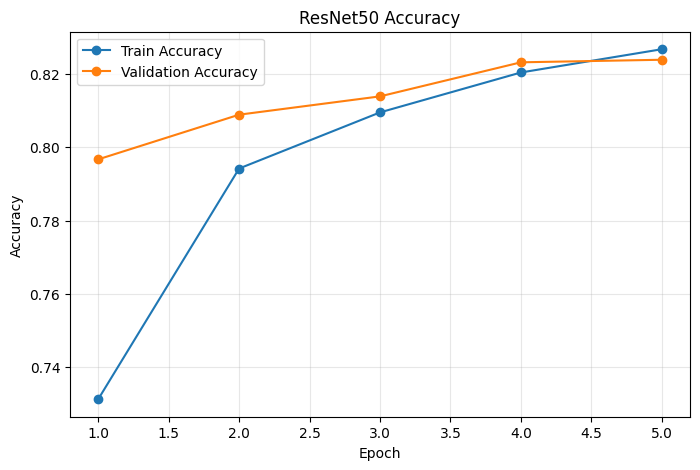

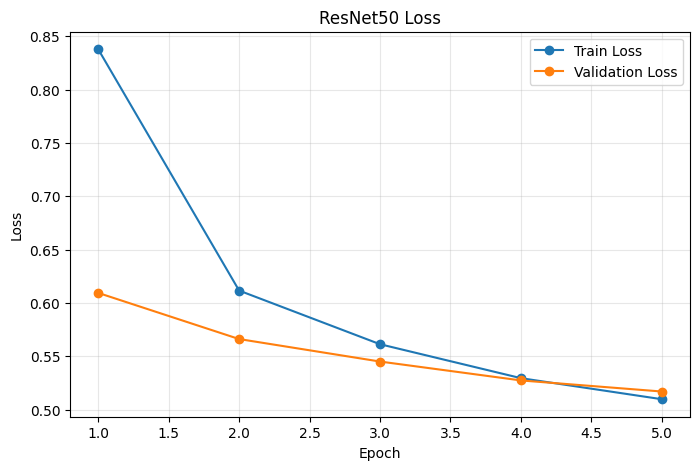

In [6]:
epochs=range(1,EPOCHS+1)
plt.figure(figsize=(8,5))
plt.plot(epochs,history["train_acc"],marker="o",label="Train Accuracy")
plt.plot(epochs,history["val_acc"],marker="o",label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("ResNet50 Accuracy")
plt.legend(); plt.grid(alpha=.3); plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs,history["train_loss"],marker="o",label="Train Loss")
plt.plot(epochs,history["val_loss"],marker="o",label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("ResNet50 Loss")
plt.legend(); plt.grid(alpha=.3); plt.show()

## 5. Test Evaluation

In [7]:
model.eval()
test_loss=correct=total=0
all_labels=[]; all_preds=[]

with torch.no_grad():
    for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        outputs=model(images)
        loss=criterion(outputs,labels)
        test_loss += loss.item()*images.size(0)
        correct += (outputs.argmax(1)==labels).sum().item()
        total += labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())

test_loss/=total
test_acc=correct/total
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4%}")

Test Loss: 0.5209
Test Accuracy: 82.5200%


## 6. Classification Report and Confusion Matrix

              precision    recall  f1-score   support

    airplane     0.8207    0.8470    0.8337      1000
  automobile     0.8826    0.8950    0.8888      1000
        bird     0.8449    0.7410    0.7896      1000
         cat     0.7071    0.7120    0.7095      1000
        deer     0.7878    0.8170    0.8022      1000
         dog     0.7702    0.8280    0.7981      1000
        frog     0.8329    0.8820    0.8567      1000
       horse     0.8927    0.7740    0.8291      1000
        ship     0.8324    0.8940    0.8621      1000
       truck     0.8998    0.8620    0.8805      1000

    accuracy                         0.8252     10000
   macro avg     0.8271    0.8252    0.8250     10000
weighted avg     0.8271    0.8252    0.8250     10000



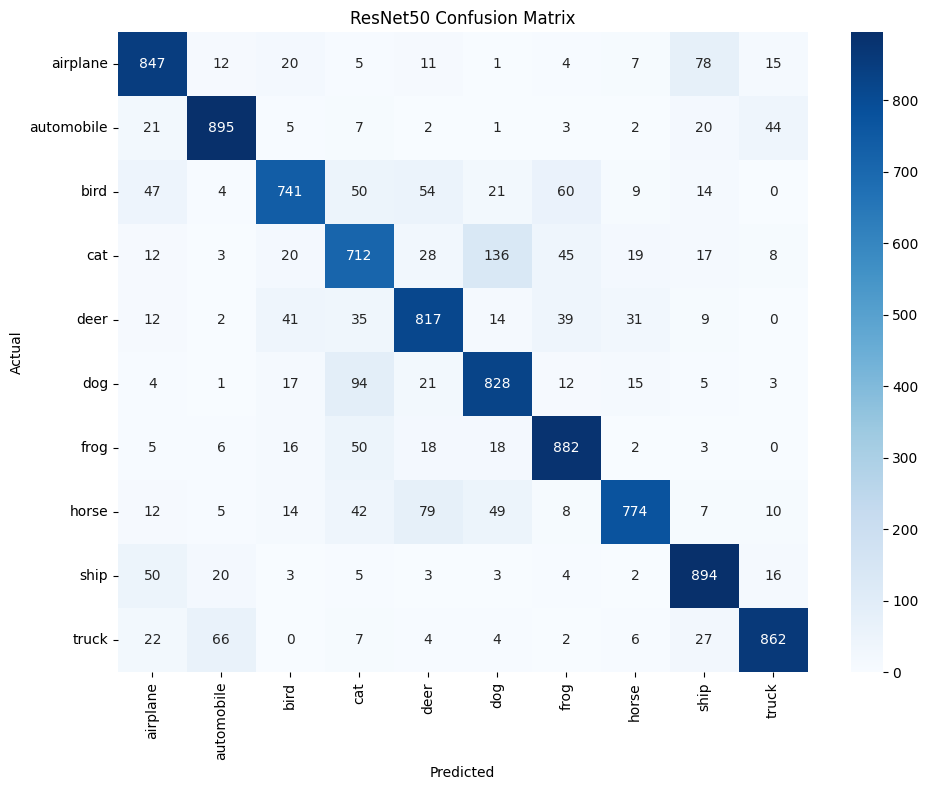

In [8]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(all_labels,all_preds,target_names=classes,digits=4))

cm=confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("ResNet50 Confusion Matrix")
plt.tight_layout(); plt.show()

## 7. Save Results

In [9]:
result=pd.DataFrame([{"Model":"ResNet50","Test Accuracy":test_acc,"Test Loss":test_loss,"Training Time (min)":training_time,"Total Parameters":total_params,"Trainable Parameters":trainable_params}])
path=RESULTS_DIR/"resnet50_results.csv"
result.to_csv(path,index=False)
display(result)
print("Saved:",path)

,Model,Test Accuracy,Test Loss,Training Time (min),Total Parameters,Trainable Parameters
0,ResNet50,0.8252,0.5209,13.475431,23528522,20490


Saved: results/resnet50_results.csv
